# Embeddings: From Characters to Positions

In this notebook, we'll explore three fundamental types of embeddings used in deep learning:

1. **Character Embeddings** - Learning representations for individual characters
2. **Word Embeddings** - Learning representations for entire words
3. **Positional Encodings** - Encoding position information in sequences

These are the building blocks of modern NLP models like Transformers!

## Setup

Let's import our dependencies and configure the environment.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns
from aiml_notebooks import get_device, set_seed, CharacterTokenizer

set_seed(42)
device = get_device()
print(f"Using device: {device}")

Using MPS (Metal Performance Shaders) for GPU acceleration
Using device: mps


## Part 1: What are Embeddings?

**The Problem**: Computers work with numbers, but text is made of symbols (characters, words). How do we convert text into numbers?

**Naive Approach**: One-hot encoding
- Represent each symbol as a vector of all zeros except one position
- Problems: High dimensionality, no semantic relationships captured

**Better Approach**: Learned embeddings
- Map each symbol to a dense, low-dimensional vector
- Let the model learn meaningful representations during training
- Similar symbols learn similar vectors

### One-Hot Encoding Example

Let's see the problem with one-hot encoding for a small vocabulary.

In [2]:
# Small vocabulary
vocab = ['cat', 'dog', 'bird', 'fish']
vocab_size = len(vocab)

# One-hot encoding
one_hot = torch.eye(vocab_size)
print("One-hot encoding:")
for i, word in enumerate(vocab):
    print(f"{word:6s}: {one_hot[i].tolist()}")

print(f"\nProblem: Each word is represented by {vocab_size} dimensions!")
print("With 10,000 words, we'd need 10,000 dimensions per word.")

One-hot encoding:
cat   : [1.0, 0.0, 0.0, 0.0]
dog   : [0.0, 1.0, 0.0, 0.0]
bird  : [0.0, 0.0, 1.0, 0.0]
fish  : [0.0, 0.0, 0.0, 1.0]

Problem: Each word is represented by 4 dimensions!
With 10,000 words, we'd need 10,000 dimensions per word.


### Embedding Layer: The Solution

PyTorch's `nn.Embedding` is a lookup table that maps integer indices to dense vectors.

In [3]:
# Create an embedding layer
embedding_dim = 3  # Much smaller than vocab_size!
embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim)

print(f"Embedding layer: {vocab_size} words -> {embedding_dim}D vectors")
print(f"\nWeight matrix shape: {embedding.weight.shape}")
print("Each row is one word's embedding vector")

Embedding layer: 4 words -> 3D vectors

Weight matrix shape: torch.Size([4, 3])
Each row is one word's embedding vector


### Looking Up Embeddings

We can retrieve embeddings by passing indices.

In [4]:
# Look up embeddings for 'cat' (index 0) and 'dog' (index 1)
indices = torch.tensor([0, 1])
embeddings = embedding(indices)

print("Embeddings (randomly initialized):")
for i, word in enumerate(['cat', 'dog']):
    print(f"{word}: {embeddings[i].detach().numpy()}")

Embeddings (randomly initialized):
cat: [0.33669037 0.1288094  0.23446237]
dog: [ 0.23033303 -1.1228564  -0.18632829]


## Part 2: Character Embeddings

Character embeddings are the simplest form - we learn a vector representation for each character in our alphabet.

**Use Cases**:
- Character-level language models
- Handling rare/unknown words
- Morphologically rich languages

Let's build a character embedding layer for English text.

### Creating a Character Vocabulary

We'll use the shared `CharacterTokenizer` to manage our character vocabulary.

In [5]:
# Sample text corpus
sample_text = "hello world! this is a sample text for character embeddings."

# Create tokenizer
tokenizer = CharacterTokenizer(sample_text)

print(f"Vocabulary size: {tokenizer.vocab_size}")
print(f"Characters: {''.join(tokenizer.chars)}")

Vocabulary size: 23
Characters: . !.abcdefghilmnoprstwx


### Building Character Embeddings

Now we create an embedding layer for our character vocabulary.

In [6]:
char_embed_dim = 8
char_embedding = nn.Embedding(tokenizer.vocab_size, char_embed_dim)

print(f"Character embedding: {tokenizer.vocab_size} chars -> {char_embed_dim}D vectors")
print(f"Total parameters: {tokenizer.vocab_size * char_embed_dim}")

Character embedding: 23 chars -> 8D vectors
Total parameters: 184


### Encoding Text

Let's encode a word and get its character embeddings.

In [7]:
word = "hello"
char_indices = torch.tensor(tokenizer.encode(word))

print(f"Word: '{word}'")
print(f"Character indices: {char_indices.tolist()}")
print(f"Characters: {[tokenizer.chars[i] for i in char_indices]}")

Word: 'hello'
Character indices: [11, 8, 13, 13, 16]
Characters: ['h', 'e', 'l', 'l', 'o']


### Getting Character Embeddings

Now we can look up the embedding for each character.

In [8]:
char_embeds = char_embedding(char_indices)

print(f"Embedded sequence shape: {char_embeds.shape}")
print(f"(sequence_length={len(word)}, embedding_dim={char_embed_dim})")
print(f"\nFirst character 'h' embedding:\n{char_embeds[0].detach().numpy()}")

Embedded sequence shape: torch.Size([5, 8])
(sequence_length=5, embedding_dim=8)

First character 'h' embedding:
[-0.98643863  0.12329912  0.34986776  0.6172807  -0.16933209  0.233225
  4.0356345   1.2794586 ]


## Part 3: Word Embeddings

Word embeddings represent entire words as dense vectors. Famous examples include Word2Vec, GloVe, and FastText.

**Key Insight**: Words used in similar contexts should have similar embeddings.
- "king" and "queen" should be close
- "car" and "automobile" should be close

We'll create a simple word embedding layer (in practice, you'd train these with methods like Word2Vec or use pretrained embeddings).

### Building a Word Vocabulary

Let's create a small word vocabulary from a corpus.

In [9]:
corpus = [
    "the cat sat on the mat",
    "the dog sat on the log",
    "cats and dogs are animals",
    "the mat is on the floor",
]

# Build vocabulary
word_to_idx = {}
for sentence in corpus:
    for word in sentence.split():
        if word not in word_to_idx:
            word_to_idx[word] = len(word_to_idx)

idx_to_word = {idx: word for word, idx in word_to_idx.items()}
vocab_size = len(word_to_idx)

print(f"Vocabulary size: {vocab_size}")
print(f"Words: {sorted(word_to_idx.keys())}")

Vocabulary size: 14
Words: ['and', 'animals', 'are', 'cat', 'cats', 'dog', 'dogs', 'floor', 'is', 'log', 'mat', 'on', 'sat', 'the']


### Creating Word Embeddings

We'll create a word embedding layer with a reasonable dimensionality.

In [10]:
word_embed_dim = 16
word_embedding = nn.Embedding(vocab_size, word_embed_dim)

print(f"Word embedding: {vocab_size} words -> {word_embed_dim}D vectors")
print(f"Total parameters: {vocab_size * word_embed_dim}")

Word embedding: 14 words -> 16D vectors
Total parameters: 224


### Encoding Sentences

Let's encode a sentence into word indices and then get embeddings.

In [11]:
sentence = "the cat sat on the mat"
word_indices = torch.tensor([word_to_idx[w] for w in sentence.split()])

print(f"Sentence: '{sentence}'")
print(f"Word indices: {word_indices.tolist()}")
print(f"Words: {[idx_to_word[i.item()] for i in word_indices]}")

Sentence: 'the cat sat on the mat'
Word indices: [0, 1, 2, 3, 0, 4]
Words: ['the', 'cat', 'sat', 'on', 'the', 'mat']


### Getting Word Embeddings

Look up embeddings for each word in the sentence.

In [12]:
word_embeds = word_embedding(word_indices)

print(f"Embedded sentence shape: {word_embeds.shape}")
print(f"(sequence_length={len(sentence.split())}, embedding_dim={word_embed_dim})")
print(f"\nFirst word 'the' embedding:\n{word_embeds[0].detach().numpy()}")

Embedded sentence shape: torch.Size([6, 16])
(sequence_length=6, embedding_dim=16)

First word 'the' embedding:
[-0.00450505  1.6667924   0.15392017 -1.0602533  -0.5726576   0.08356804
  0.39990535  1.9892071  -0.07198751 -0.90609455 -2.0487123  -1.0810553
  0.01762322  0.07822598  0.19315828  0.4096734 ]


### Visualizing Word Embeddings

Let's visualize our word embeddings in 2D using PCA to see if similar words cluster together (note: these are random, untrained embeddings).

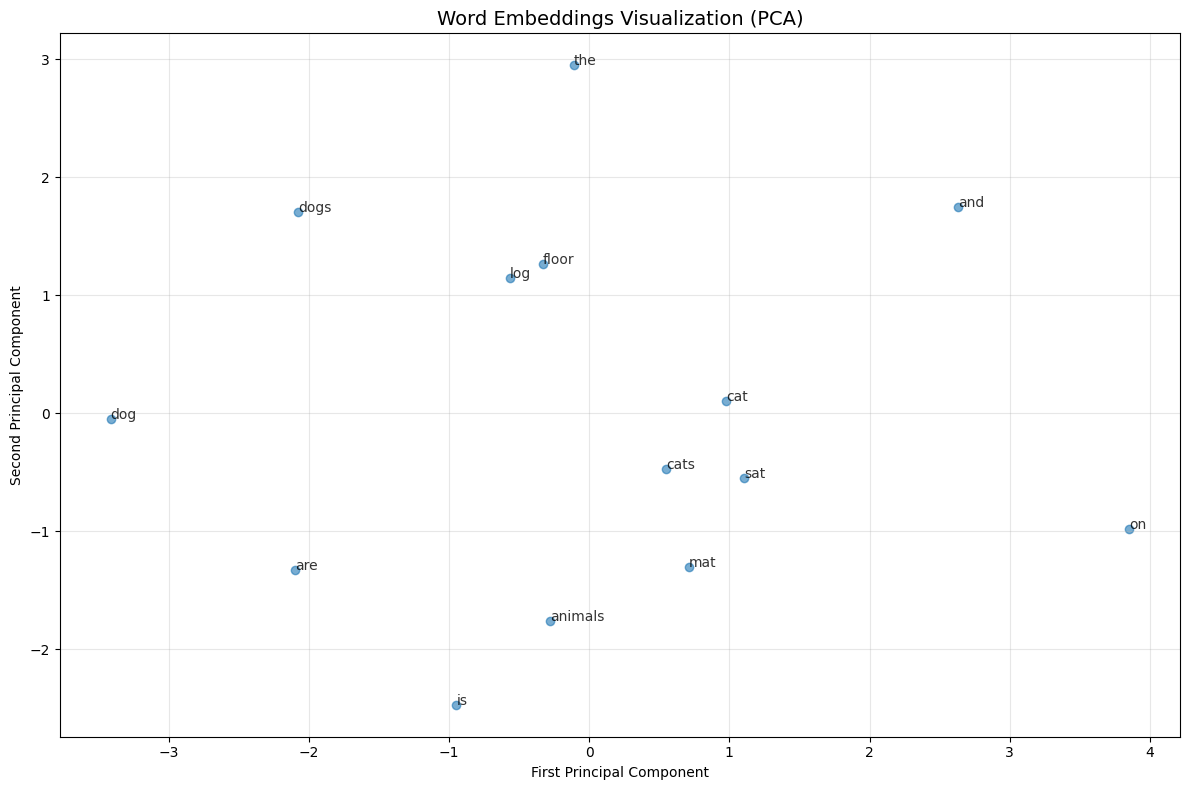

Note: These are randomly initialized embeddings.
With training, similar words would cluster together!


In [13]:
# Get all word embeddings
all_embeddings = word_embedding.weight.detach().numpy()

# Reduce to 2D using PCA
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(all_embeddings)

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6)

# Annotate each point
for idx, word in idx_to_word.items():
    plt.annotate(word, (embeddings_2d[idx, 0], embeddings_2d[idx, 1]), 
                 fontsize=10, alpha=0.8)

plt.title('Word Embeddings Visualization (PCA)', fontsize=14)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Note: These are randomly initialized embeddings.")
print("With training, similar words would cluster together!")

## Part 4: Positional Encodings

**The Problem**: Embeddings don't capture position information.
- "cat sat on mat" vs "mat sat on cat" would have identical embeddings
- But these sentences have different meanings!

**Solution**: Add positional information to embeddings.

Two main approaches:
1. **Learned Positional Embeddings**: Just another embedding layer for positions
2. **Sinusoidal Positional Encodings**: Fixed mathematical function (used in original Transformer)

### Approach 1: Learned Positional Embeddings

We create an embedding layer where each position gets its own learned vector.

In [14]:
max_seq_len = 20  # Maximum sequence length we'll support
pos_embed_dim = 16  # Should match word embedding dimension

# Positional embedding layer
pos_embedding = nn.Embedding(max_seq_len, pos_embed_dim)

print(f"Positional embedding: {max_seq_len} positions -> {pos_embed_dim}D vectors")
print(f"Total parameters: {max_seq_len * pos_embed_dim}")

Positional embedding: 20 positions -> 16D vectors
Total parameters: 320


### Adding Position Information

For a sequence, we add the positional embedding to each word embedding.

In [15]:
sentence = "the cat sat on the mat"
word_indices = torch.tensor([word_to_idx[w] for w in sentence.split()])
seq_len = len(word_indices)

# Get word embeddings
word_embeds = word_embedding(word_indices)

# Get positional embeddings (0, 1, 2, ..., seq_len-1)
positions = torch.arange(seq_len)
pos_embeds = pos_embedding(positions)

# Combine: word embeddings + positional embeddings
combined_embeds = word_embeds + pos_embeds

print(f"Word embeddings shape: {word_embeds.shape}")
print(f"Positional embeddings shape: {pos_embeds.shape}")
print(f"Combined embeddings shape: {combined_embeds.shape}")
print(f"\nFirst token ('the' at position 0):")
print(f"Word embedding:      {word_embeds[0][:4].detach().numpy()}...")
print(f"Positional embedding: {pos_embeds[0][:4].detach().numpy()}...")
print(f"Combined:            {combined_embeds[0][:4].detach().numpy()}...")

Word embeddings shape: torch.Size([6, 16])
Positional embeddings shape: torch.Size([6, 16])
Combined embeddings shape: torch.Size([6, 16])

First token ('the' at position 0):
Word embedding:      [-0.00450505  1.6667924   0.15392017 -1.0602533 ]...
Positional embedding: [-1.3838842   0.48687157 -1.0020297   0.03294881]...
Combined:            [-1.3883892  2.1536639 -0.8481095 -1.0273044]...


### Approach 2: Sinusoidal Positional Encoding

The original Transformer paper used a fixed positional encoding based on sine and cosine functions.

**Formula**: For position $pos$ and dimension $i$:

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d}}\right)$$

**Why?** 
- No learned parameters
- Can extrapolate to longer sequences than seen during training
- Each dimension oscillates at different frequencies

### Implementing Sinusoidal Encoding

Let's implement the sinusoidal positional encoding function.

In [16]:
def get_sinusoidal_encoding(seq_len, d_model):
    """
    Generate sinusoidal positional encoding.
    
    Args:
        seq_len: Maximum sequence length
        d_model: Embedding dimension
    
    Returns:
        Positional encoding tensor of shape (seq_len, d_model)
    """
    encoding = torch.zeros(seq_len, d_model)
    position = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1)
    
    # Compute the div_term: 1 / 10000^(2i/d_model)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * 
                        (-np.log(10000.0) / d_model))
    
    # Apply sin to even indices
    encoding[:, 0::2] = torch.sin(position * div_term)
    
    # Apply cos to odd indices
    encoding[:, 1::2] = torch.cos(position * div_term)
    
    return encoding

# Generate sinusoidal encodings
sin_pos_encoding = get_sinusoidal_encoding(max_seq_len, pos_embed_dim)

print(f"Sinusoidal encoding shape: {sin_pos_encoding.shape}")
print(f"Parameters: 0 (it's fixed!)")

Sinusoidal encoding shape: torch.Size([20, 16])
Parameters: 0 (it's fixed!)


### Visualizing Sinusoidal Encodings

Let's visualize how the encoding changes across positions and dimensions.

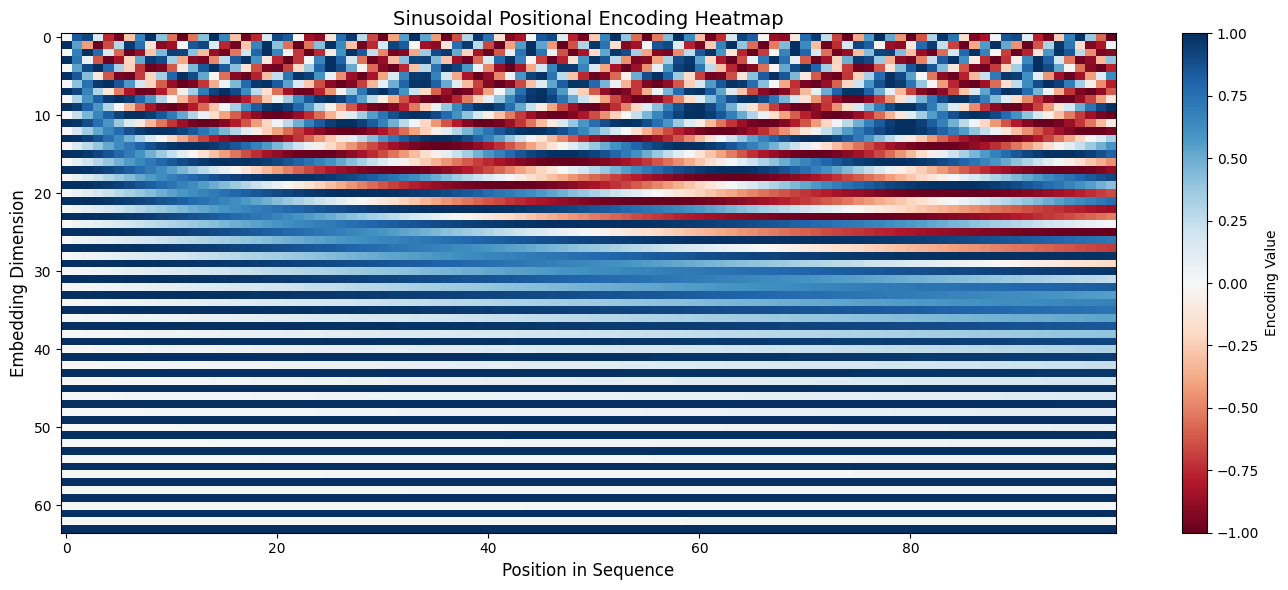

Notice the wave patterns!
- Lower dimensions (bottom) change slowly across positions
- Higher dimensions (top) oscillate more rapidly


In [17]:
# Create a larger encoding for better visualization
vis_seq_len = 100
vis_d_model = 64
vis_encoding = get_sinusoidal_encoding(vis_seq_len, vis_d_model)

plt.figure(figsize=(14, 6))
plt.imshow(vis_encoding.T.numpy(), aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar(label='Encoding Value')
plt.xlabel('Position in Sequence', fontsize=12)
plt.ylabel('Embedding Dimension', fontsize=12)
plt.title('Sinusoidal Positional Encoding Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

print("Notice the wave patterns!")
print("- Lower dimensions (bottom) change slowly across positions")
print("- Higher dimensions (top) oscillate more rapidly")

### Frequency Patterns Across Dimensions

Let's visualize how a few dimensions vary across positions.

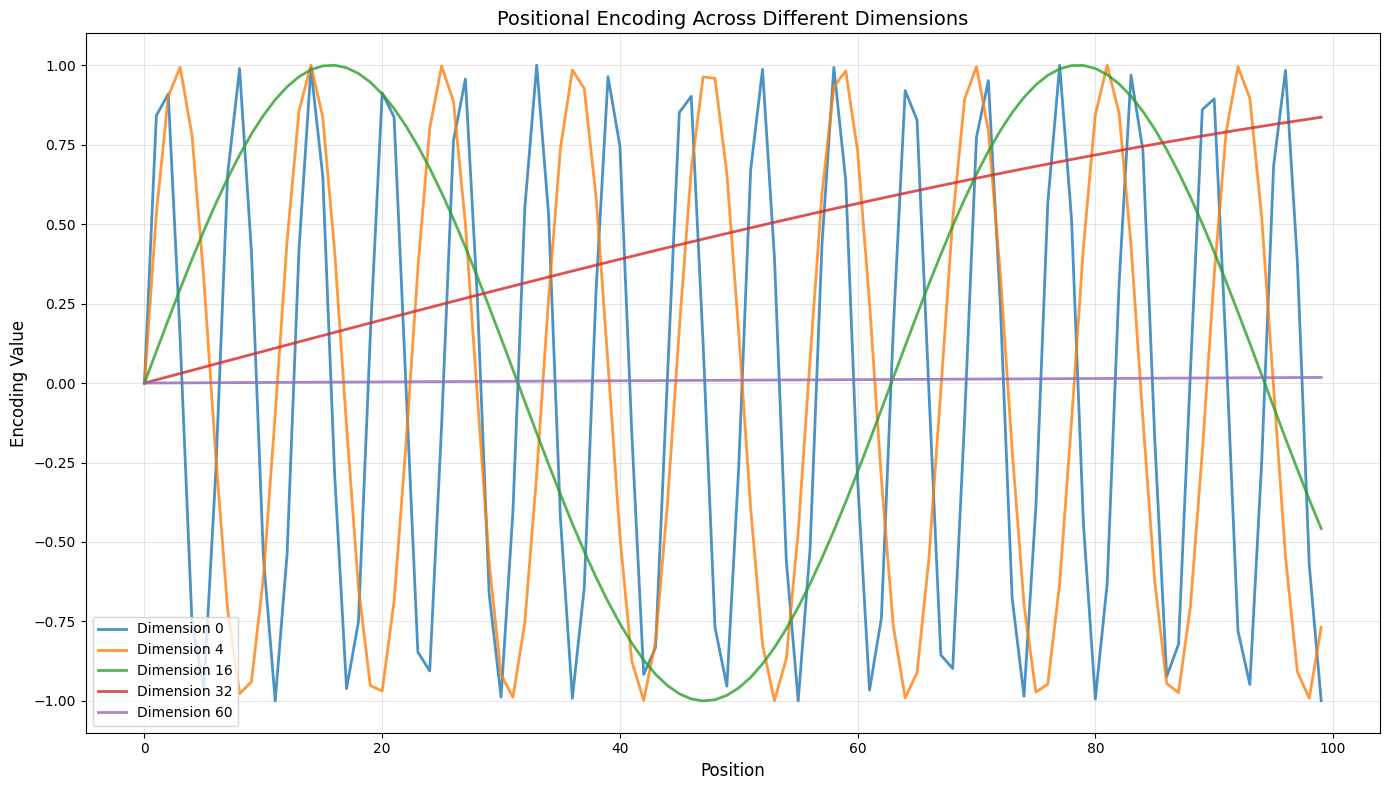

Each dimension captures position information at different scales!


In [18]:
positions = np.arange(vis_seq_len)
dims_to_plot = [0, 4, 16, 32, 60]

plt.figure(figsize=(14, 8))
for dim in dims_to_plot:
    plt.plot(positions, vis_encoding[:, dim].numpy(), 
             label=f'Dimension {dim}', linewidth=2, alpha=0.8)

plt.xlabel('Position', fontsize=12)
plt.ylabel('Encoding Value', fontsize=12)
plt.title('Positional Encoding Across Different Dimensions', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Each dimension captures position information at different scales!")

### Using Sinusoidal Encoding with Word Embeddings

Now let's combine sinusoidal encodings with our word embeddings.

In [19]:
sentence = "the cat sat on the mat"
word_indices = torch.tensor([word_to_idx[w] for w in sentence.split()])
seq_len = len(word_indices)

# Get word embeddings
word_embeds = word_embedding(word_indices)

# Get sinusoidal positional encodings
sin_pos_embeds = sin_pos_encoding[:seq_len]

# Combine
combined_sin_embeds = word_embeds + sin_pos_embeds

print(f"Word embeddings shape: {word_embeds.shape}")
print(f"Sinusoidal encodings shape: {sin_pos_embeds.shape}")
print(f"Combined embeddings shape: {combined_sin_embeds.shape}")

Word embeddings shape: torch.Size([6, 16])
Sinusoidal encodings shape: torch.Size([6, 16])
Combined embeddings shape: torch.Size([6, 16])


## Part 5: Comparing Positional Encoding Methods

Let's compare learned vs. sinusoidal positional encodings.

### Learned vs. Sinusoidal: Side by Side

Visualize both methods for the same positions.

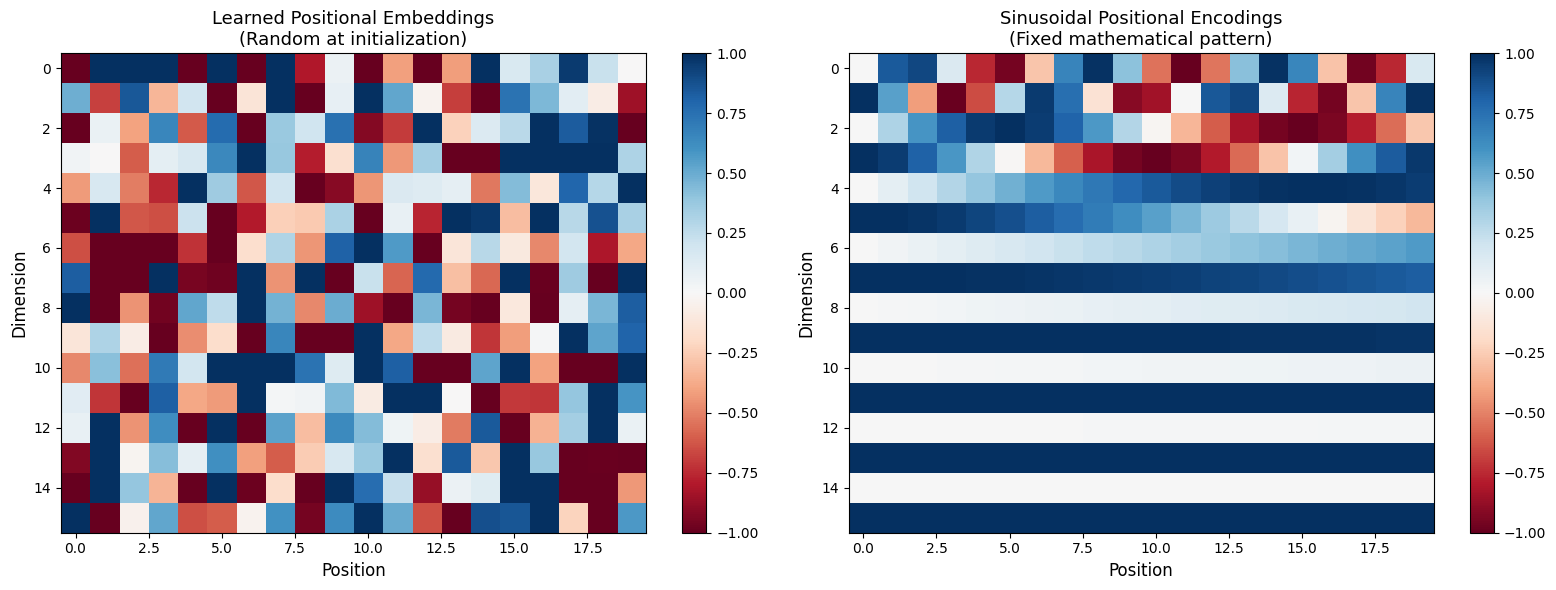

Key differences:
- Learned: Random initially, must be trained, limited to max_seq_len
- Sinusoidal: Fixed pattern, no training needed, can extrapolate to any length


In [20]:
# Get learned positional embeddings
learned_pos = pos_embedding.weight.detach().numpy()

# Get sinusoidal encodings
sinusoidal_pos = sin_pos_encoding.numpy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Learned
im1 = axes[0].imshow(learned_pos.T, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
axes[0].set_xlabel('Position', fontsize=12)
axes[0].set_ylabel('Dimension', fontsize=12)
axes[0].set_title('Learned Positional Embeddings\n(Random at initialization)', fontsize=13)
plt.colorbar(im1, ax=axes[0])

# Sinusoidal
im2 = axes[1].imshow(sinusoidal_pos.T, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
axes[1].set_xlabel('Position', fontsize=12)
axes[1].set_ylabel('Dimension', fontsize=12)
axes[1].set_title('Sinusoidal Positional Encodings\n(Fixed mathematical pattern)', fontsize=13)
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

print("Key differences:")
print("- Learned: Random initially, must be trained, limited to max_seq_len")
print("- Sinusoidal: Fixed pattern, no training needed, can extrapolate to any length")

### Positional Encoding Trade-offs

Let's summarize the pros and cons of each approach.

In [21]:
comparison = {
    'Property': ['Parameters', 'Extrapolation', 'Training', 'Pattern', 'Used in'],
    'Learned': [
        f'{max_seq_len * pos_embed_dim} (max_seq × d_model)',
        'Limited to max_seq_len',
        'Requires training',
        'Data-dependent',
        'BERT, GPT-2'
    ],
    'Sinusoidal': [
        '0 (fixed function)',
        'Any sequence length',
        'No training needed',
        'Fixed periodic waves',
        'Original Transformer'
    ]
}

import pandas as pd
df = pd.DataFrame(comparison)
print(df.to_string(index=False))

     Property                 Learned           Sinusoidal
   Parameters 320 (max_seq × d_model)   0 (fixed function)
Extrapolation  Limited to max_seq_len  Any sequence length
     Training       Requires training   No training needed
      Pattern          Data-dependent Fixed periodic waves
      Used in             BERT, GPT-2 Original Transformer


## Part 6: Practical Example - Complete Embedding Pipeline

Let's put it all together in a realistic example: embedding a batch of sentences.

### Creating an Embedding Module

We'll build a PyTorch module that handles word embeddings + positional encodings.

In [22]:
class EmbeddingWithPosition(nn.Module):
    def __init__(self, vocab_size, d_model, max_seq_len, use_sinusoidal=True):
        super().__init__()
        self.d_model = d_model
        self.use_sinusoidal = use_sinusoidal
        
        # Word embeddings
        self.word_embedding = nn.Embedding(vocab_size, d_model)
        
        if use_sinusoidal:
            # Register sinusoidal encoding as a buffer (not a parameter)
            self.register_buffer('pos_encoding', 
                               get_sinusoidal_encoding(max_seq_len, d_model))
        else:
            # Learned positional embeddings
            self.pos_embedding = nn.Embedding(max_seq_len, d_model)
    
    def forward(self, x):
        """
        Args:
            x: Input tensor of shape (batch_size, seq_len)
        Returns:
            Embedded tensor of shape (batch_size, seq_len, d_model)
        """
        batch_size, seq_len = x.shape
        
        # Get word embeddings
        word_embeds = self.word_embedding(x)  # (batch_size, seq_len, d_model)
        
        if self.use_sinusoidal:
            # Add sinusoidal positional encoding
            pos_embeds = self.pos_encoding[:seq_len, :]  # (seq_len, d_model)
        else:
            # Add learned positional embeddings
            positions = torch.arange(seq_len, device=x.device)
            pos_embeds = self.pos_embedding(positions)  # (seq_len, d_model)
        
        # Combine (broadcasting handles batch dimension)
        return word_embeds + pos_embeds

# Create embedding modules
d_model = 32
embed_sinusoidal = EmbeddingWithPosition(vocab_size, d_model, max_seq_len, use_sinusoidal=True)
embed_learned = EmbeddingWithPosition(vocab_size, d_model, max_seq_len, use_sinusoidal=False)

print("Sinusoidal embedding module:")
print(f"  Word embedding params: {vocab_size * d_model}")
print(f"  Positional encoding params: 0")
print(f"  Total: {sum(p.numel() for p in embed_sinusoidal.parameters())}")

print("\nLearned embedding module:")
print(f"  Word embedding params: {vocab_size * d_model}")
print(f"  Positional embedding params: {max_seq_len * d_model}")
print(f"  Total: {sum(p.numel() for p in embed_learned.parameters())}")

Sinusoidal embedding module:
  Word embedding params: 448
  Positional encoding params: 0
  Total: 448

Learned embedding module:
  Word embedding params: 448
  Positional embedding params: 640
  Total: 1088


### Processing a Batch of Sentences

Let's encode multiple sentences and process them as a batch.

In [23]:
sentences = [
    "the cat sat on the mat",
    "the dog sat on the log",
    "cats and dogs are animals",
]

# Tokenize and pad to same length
tokenized = [[word_to_idx.get(w, 0) for w in sent.split()] for sent in sentences]
max_len = max(len(t) for t in tokenized)

# Pad sequences
padded = [t + [0] * (max_len - len(t)) for t in tokenized]
batch = torch.tensor(padded)

print(f"Batch shape: {batch.shape} (batch_size=3, seq_len={max_len})")
print(f"\nBatch tensor:\n{batch}")

Batch shape: torch.Size([3, 6]) (batch_size=3, seq_len=6)

Batch tensor:
tensor([[ 0,  1,  2,  3,  0,  4],
        [ 0,  5,  2,  3,  0,  6],
        [ 7,  8,  9, 10, 11,  0]])


### Getting Embeddings for the Batch

Process the entire batch through our embedding module.

In [24]:
# Get embeddings with sinusoidal encoding
embedded_batch = embed_sinusoidal(batch)

print(f"Embedded batch shape: {embedded_batch.shape}")
print(f"(batch_size={batch.shape[0]}, seq_len={batch.shape[1]}, d_model={d_model})")
print(f"\nFirst sentence, first token embedding (first 8 dims):")
print(embedded_batch[0, 0, :8].detach().numpy())

Embedded batch shape: torch.Size([3, 6, 32])
(batch_size=3, seq_len=6, d_model=32)

First sentence, first token embedding (first 8 dims):
[ 0.34436318 -2.1016061  -1.4587226  -0.43182576 -0.6071269   0.7402621
 -0.71901876  0.61416906]


### Visualizing Batch Embeddings

Let's visualize the embeddings for all sentences in our batch.

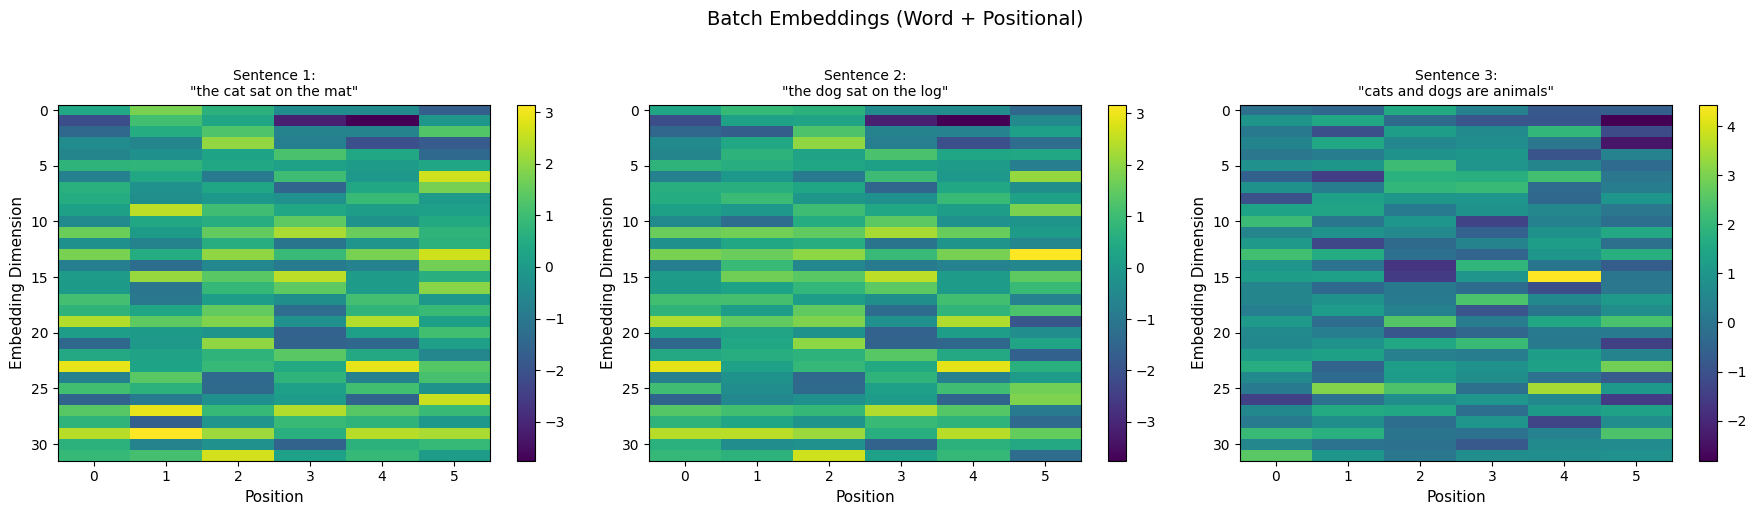

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (ax, sent) in enumerate(zip(axes, sentences)):
    embeds = embedded_batch[i].detach().numpy()
    im = ax.imshow(embeds.T, aspect='auto', cmap='viridis')
    ax.set_xlabel('Position', fontsize=11)
    ax.set_ylabel('Embedding Dimension', fontsize=11)
    ax.set_title(f'Sentence {i+1}:\n"{sent}"', fontsize=10)
    plt.colorbar(im, ax=ax)

plt.suptitle('Batch Embeddings (Word + Positional)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Summary

We've explored three fundamental types of embeddings:

### 1. Character Embeddings
- Map individual characters to vectors
- Useful for handling rare words and morphology
- Smaller vocabulary than word embeddings

### 2. Word Embeddings
- Map entire words to dense vectors
- Capture semantic relationships
- Can be pretrained (Word2Vec, GloVe) or learned from scratch

### 3. Positional Encodings
- Add position information to embeddings
- Two approaches:
  - **Learned**: More parameters, limited extrapolation
  - **Sinusoidal**: No parameters, infinite extrapolation

### Key Takeaways
- Embeddings convert discrete tokens into continuous vectors
- Position matters! Add positional encodings for sequence models
- These are the input layer for modern NLP models (Transformers, RNNs, etc.)

## Next Steps

Now that you understand embeddings, you can:
- Use them as inputs to RNNs, LSTMs, or Transformers
- Experiment with different embedding dimensions
- Load pretrained word embeddings (GloVe, Word2Vec)
- Build your own embedding models (Word2Vec, CBOW, Skip-gram)
- Explore more advanced positional encodings (relative, rotary)